<a href="https://colab.research.google.com/github/juliamartin23/ML-Model/blob/main/Copy_of_Exploratory_Data_Analysis_for_Website_Copy1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Retrieval

## Get Data from Reddit: r/Opiates and r/OpiatesRecovery

In [ ]:
# import packages
import datetime as dt
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import pandas as pd
import praw
from psaw import PushshiftAPI
from sklearn.feature_extraction.text import CountVectorizer
from textblob import TextBlob

In [ ]:
# generates PushshiftAPI for PSAW
api = PushshiftAPI()

In [ ]:
# get data from 2018 to present
start_date = int(dt.datetime(2018, 1, 1).timestamp())

# api instances for both the opiates and opiatesRecovery subreddits
opiates_recovery = api.search_submissions(
    after=start_date,
    subreddit="OpiatesRecovery",
    filter=[
        "author",
        "created",
        "id",
        "num_comments",
        "permalink",
        "score",
        "selftext",
        "subreddit",
        "title",
        "upvote_ratio",
        "url",
    ],
)
opiates = api.search_submissions(
    after=start_date,
    subreddit="Opiates",
    filter=[
        "author",
        "created",
        "id",
        "num_comments",
        "permalink",
        "score",
        "selftext",
        "subreddit",
        "title",
        "upvote_ratio",
        "url",
    ],
)

In [ ]:
# based on a subreddit returned by api.search_submissions function, returns a
# dataframe with all features of each submission
def get_submission_data(sub_reddit):
    submission_list = list()
    for submissions in sub_reddit:
        submission_list.append(submissions.d_)
    return pd.DataFrame(submission_list)

In [ ]:
# generates df with submissions from OpiatesRecovery subreddit, update
# date format, generate csv to save
opiates_recovery = get_submission_data(opiates_recovery)
opiates_recovery['created'] = pd.to_datetime(opiates_recovery_df['created'], unit='s')
opiates_recovery.to_csv('opiates_recovery_data.csv')

In [ ]:
# generates df with submissions from Opiates subreddit, update
# date format, generate csv to save
opiates = get_submission_data(opiates)
opiates['created'] = pd.to_datetime(opiates_df['created'], unit='s')
opiates.to_csv('opiates_data.csv')

# Data Exploration and Visualization

## Data Configuration

In [ ]:
# generates alternate date formats
opiates["month_year"] = [
    str(month_year) for month_year in opiates["created"].dt.strftime("%Y-%m")
]
opiates["month"] = opiates["created"].dt.month
opiates["year"] = opiates["created"].dt.year
print(opiates.head())

   Unnamed: 0              author  created_utc      id  num_comments  \
0           0      iammyowndoctor   1649898971  u35krj             1   
1           1      ConstantAd1481   1649898958  u35klj             1   
2           2        MargielaFien   1649895989  u34m7z             1   
3           3  Slashgingerflasher   1649895348  u34ez8             1   
4           4     fxckingchildish   1649894376  u343fl             1   

                                           permalink  score  \
0  /r/opiates/comments/u35krj/anyone_managed_to_d...      1   
1  /r/opiates/comments/u35klj/how_normal_is_being...      1   
2  /r/opiates/comments/u34m7z/anyone_who_can_help...      1   
3  /r/opiates/comments/u34ez8/should_i_narcan_mys...      1   
4         /r/opiates/comments/u343fl/trying_to_quit/      1   

                                            selftext subreddit  \
0  Maybe it's cause I know so much HR, but I've p...   opiates   
1  so i can take a whole oxy/fentoxy and not be s...   o

In [ ]:
# generates alternate date formats
opiates_recovery["month_year"] = [
    str(month_year) for month_year in opiates_recovery["created"].dt.strftime("%Y-%m")
]
opiates_recovery["month"] = opiates_recovery["created"].dt.month
opiates_recovery["year"] = opiates_recovery["created"].dt.year
print(opiates_recovery.head())

   Unnamed: 0             author  created_utc      id  num_comments  \
0           0             -T_rx-   1649893733  u33vy1             0   
1           1       BongoFan4evs   1649892570  u33hxj             0   
2           2           Mnice123   1649890458  u32rdw             0   
3           3  inflatablepickle8   1649889947  u32l2y             0   
4           4        LoloSniffen   1649889060  u32adu             0   

                                           permalink  score  \
0  /r/OpiatesRecovery/comments/u33vy1/33_days_now...      1   
1  /r/OpiatesRecovery/comments/u33hxj/one_year_to...      1   
2  /r/OpiatesRecovery/comments/u32rdw/i_guess_peo...      1   
3    /r/OpiatesRecovery/comments/u32l2y/the_anxiety/      1   
4  /r/OpiatesRecovery/comments/u32adu/how_long_do...      1   

                                            selftext        subreddit  \
0  Hey guy's ... I've just wanted to let you know...  OpiatesRecovery   
1  Today my doctor informed me that it was one y

In [ ]:
# add additional features to the dataframe
# lengths of posts and titles
opiates["word_count_post"] = opiates["selftext"].apply(lambda x: len(str(x).split()))
opiates["word_count_title"] = opiates["title"].apply(lambda x: len(str(x).split()))
opiates_recovery["word_count_post"] = opiates_recovery["selftext"].apply(
    lambda x: len(str(x).split())
)
opiates_recovery["word_count_title"] = opiates_recovery["title"].apply(
    lambda x: len(str(x).split())
)
# sentiment analysis using TextBlob
opiates["title_sentiment_polarity"] = [
    TextBlob(str(x)).sentiment.polarity for x in opiates["title"]
]
opiates["post_sentiment_polarity"] = [
    TextBlob(str(x)).sentiment.polarity for x in opiates["selftext"]
]
opiates_recovery["title_sentiment_polarity"] = [
    TextBlob(str(x)).sentiment.polarity for x in opiates_recovery["title"]
]
opiates_recovery["post_sentiment_polarity"] = [
    TextBlob(str(x)).sentiment.polarity for x in opiates_recovery["selftext"]
]

## Submissions by Time

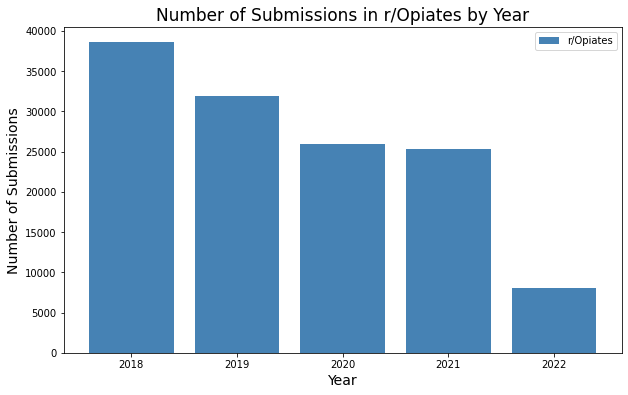

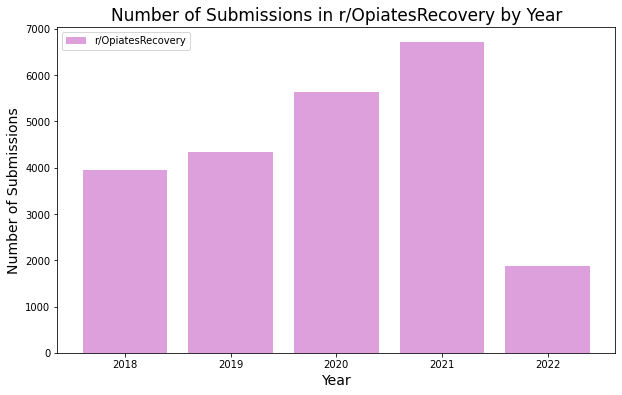

In [ ]:
# plots the number of posts by year from the r/OpiatesRecovery and
# r/Opiates subreddits

# gets counts by years for different subreddits
year_opiates_recovery = opiates_recovery.groupby(by=[opiates_recovery.year]).count()
year_opiates = opiates.groupby(by=[opiates.year]).count()
years = year_opiates_recovery.index
count_opiates = year_opiates.id
count_opiates_recovery = year_opiates_recovery.id

# plots r/Opiates
plt.figure(figsize=(10, 6))
width = 0.8
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Submissions", fontsize=14)
plt.bar(years, count_opiates, width, label="r/Opiates", color="steelblue")
plt.legend()
plt.title("Number of Submissions in r/Opiates by Year", fontsize=17)
plt.savefig("Number of Submissions in Opiates by Year.jpeg") #save as jpeg
plt.show()

# plots r/OpiatesRecovery
plt.figure(figsize=(10, 6))
width = 0.8
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Submissions", fontsize=14)
plt.bar(years, count_opiates_recovery, width, label = "r/OpiatesRecovery", color="plum")
plt.legend()
plt.title("Number of Submissions in r/OpiatesRecovery by Year", fontsize=17)
plt.savefig("Number of Submissions in OpiatesRecovery by Year.jpeg") #save as jpeg
plt.show()

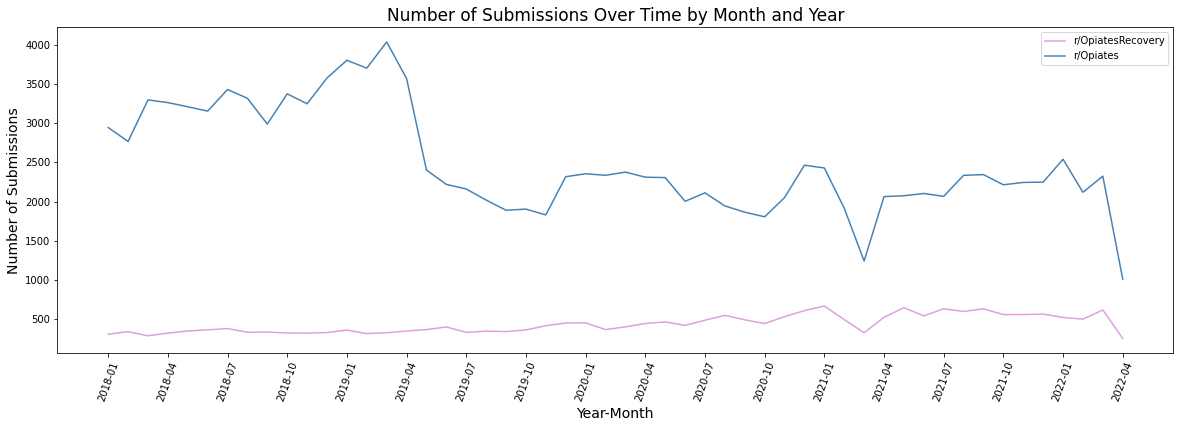

In [ ]:
# plots the number of posts by month and year from 2018 to 2022 from the r/OpiatesRecovery and
# r/Opiates subreddits

# gets counts by month-year
time_opiates_recovery = opiates_recovery.groupby(
    by=[opiates_recovery.month_year]
).count()
time_opiates = opiates.groupby(by=[opiates.month_year]).count()

# plots figure with r/Opiates and r/OpiatesRecovery
plt.figure(figsize=(20, 6))
plt.plot(
    time_opiates_recovery.index, time_opiates_recovery.id, label="r/OpiatesRecovery", color="plum"
)
plt.plot(time_opiates.index, time_opiates.id, label="r/Opiates", color="steelblue")
plt.legend()
ticks = [j for i, j in enumerate(time_opiates_recovery.index) if not i % 3]
labels = [label for i, label in enumerate(time_opiates_recovery.index) if not i % 3]
plt.xticks(ticks, labels, rotation=70)  # set new X axis ticks and labels
plt.xlabel("Year-Month", fontsize=14)
plt.ylabel("Number of Submissions", fontsize=14)
plt.title("Number of Submissions Over Time by Month and Year", fontsize=17)
plt.savefig("Number of Submissions Over Time by Month and Year.jpeg") #save as jpeg
plt.show()

## Submissions by Sentiment

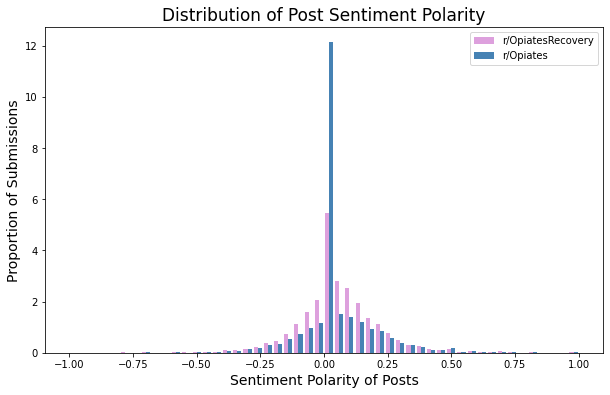

In [ ]:
# plots histogram of post sentiment distribution of r/Opiates and r/OpiatesRecovery
plt.figure(figsize=(10, 6))
plt.hist(
    [opiates_recovery.post_sentiment_polarity, opiates.post_sentiment_polarity],
    bins=50,
    density=True,
    label=["r/OpiatesRecovery", "r/Opiates"],
    color=["plum","steelblue"]
)
plt.xlabel("Sentiment Polarity of Posts", fontsize=14)
plt.ylabel("Proportion of Submissions", fontsize=14)
plt.title("Distribution of Post Sentiment Polarity", fontsize=17)
plt.savefig("Distribution of Post Sentiment Polarity.jpeg") #save as jpeg
plt.legend()
plt.show()

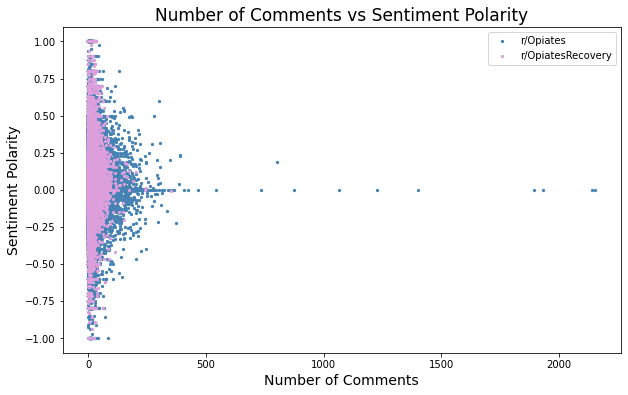

In [ ]:
# plots the sentiment analysis of post by the number of comments
# for r/Opiates and r/OpiatesRecovery
plt.figure(figsize=(10, 6))
plt.scatter(
    opiates.num_comments,
    opiates.post_sentiment_polarity,
    s=5,
    label="r/Opiates",
    color="steelblue",
)
plt.scatter(
    opiates_recovery.num_comments,
    opiates_recovery.post_sentiment_polarity,
    label="r/OpiatesRecovery",
    s=5,
    color="plum",
)
plt.xlabel("Number of Comments", fontsize=14)
plt.ylabel("Sentiment Polarity", fontsize=14)
plt.legend()
plt.title("Number of Comments vs Sentiment Polarity", fontsize=17)
plt.savefig("Number of Comments vs Sentiment Polarity.jpeg") #save as jpeg
plt.show()

## Submission n-grams

In [ ]:
# gets rid of words in posts that indiciate a link to another post so focus on meaning
# of the posts instead
def remove_link_words(corpus):
    link_related_words = ["www", "https", "youtube", "com", "reddit"]
    for word in link_related_words:
        corpus = [item.lower().replace(word, "") for item in corpus]
    return corpus

# function to determine the top number of n-grams of given length
# https://towardsdatascience.com/a-complete-exploratory-data-analysis-and-visualization-for-text-data-29fb1b96fb6a
def get_top_n_words(corpus, n, length_ngram):
    corpus = remove_link_words(corpus)
    vec = CountVectorizer(
        stop_words="english", ngram_range=(length_ngram, length_ngram)
    ).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# gets rid of null text
cleaned_opiates_text = opiates[opiates["selftext"].notnull()]
cleaned_opiates_recovery_text = opiates_recovery[opiates_recovery["selftext"].notnull()]

# top words
common_words_opiates = get_top_n_words(cleaned_opiates_text["selftext"], 20, 1)
common_words_opiates_recovery = get_top_n_words(
    cleaned_opiates_recovery_text["selftext"], 20, 1
)

# top bigrams
common_bigrams_opiates = get_top_n_words(cleaned_opiates_text["selftext"], 20, 2)
common_bigrams_opiates_recovery = get_top_n_words(
    cleaned_opiates_recovery_text["selftext"], 20, 2
)

# top trigrams
common_trigrams_opiates = get_top_n_words(cleaned_opiates_text["selftext"], 20, 3)
common_trigrams_opiates_recovery = get_top_n_words(
    cleaned_opiates_recovery_text["selftext"], 20, 3
)

# top 4grams
common_4grams_opiates = get_top_n_words(cleaned_opiates_text["selftext"], 20, 4)
common_4grams_opiates_recovery = get_top_n_words(
    cleaned_opiates_recovery_text["selftext"], 20, 4
)

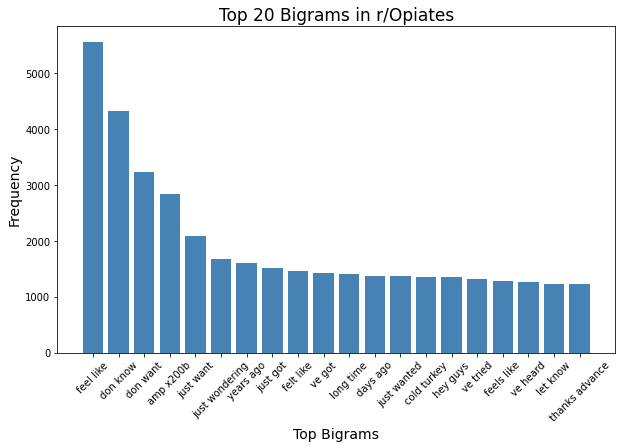

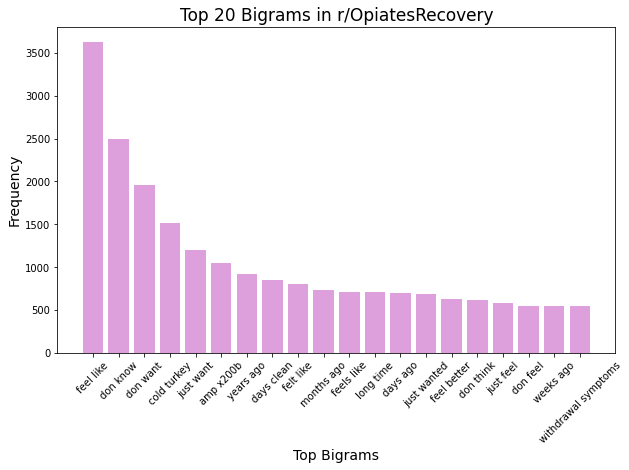

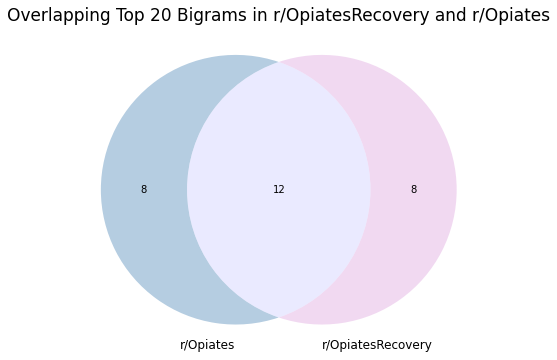

Overlapping Top 20 Bigrams in r/OpiatesRecovery and r/Opiates {'just wanted', 'feel like', 'amp x200b', 'just want', 'cold turkey', 'don want', 'feels like', 'don know', 'days ago', 'felt like', 'long time', 'years ago'}


In [ ]:
# visualization of bigram frequency data r/Opiates
words_opiates = [word[0] for word in common_bigrams_opiates]
frequencies_opiates = [word[1] for word in common_bigrams_opiates]
plt.figure(figsize=(10, 6))
plt.bar(words_opiates, frequencies_opiates, color="steelblue")
plt.xticks(rotation=45)
plt.xlabel("Top Bigrams", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Top 20 Bigrams in r/Opiates", fontsize=17)
plt.savefig("Top 20 Bigrams in Opiates.jpeg") #save as jpeg
plt.show()

# visualization of bigram frequency data r/OpiatesRecovery
words_opiates_recovery = [word[0] for word in common_bigrams_opiates_recovery]
frequencies_opiates_recovery = [word[1] for word in common_bigrams_opiates_recovery]
plt.figure(figsize=(10, 6))
plt.bar(words_opiates_recovery, frequencies_opiates_recovery, color="plum")
plt.xticks(rotation=45)
plt.xlabel("Top Bigrams", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Top 20 Bigrams in r/OpiatesRecovery", fontsize=17)
plt.savefig("Top 20 Bigrams in OpiatesRecovery.jpeg") #save as jpeg
plt.show()

# venn diagram of overlapping bigrams between subreddits
plt.figure(figsize=(10, 6))
venn2(
    subsets=[set(words_opiates), set(words_opiates_recovery)],
    set_labels=("r/Opiates", "r/OpiatesRecovery"),
    set_colors=("steelblue", "plum"),
)  # 2-element list of set objects
plt.title("Overlapping Top 20 Bigrams in r/OpiatesRecovery and r/Opiates", fontsize=17)
plt.savefig("Overlapping Top 20 Bigrams in OpiatesRecovery and Opiates.jpeg") #save as jpeg
plt.show()
print(
    f"Overlapping Top 20 Bigrams in r/OpiatesRecovery and r/Opiates {set(words_opiates).intersection(set(words_opiates_recovery))}"
)

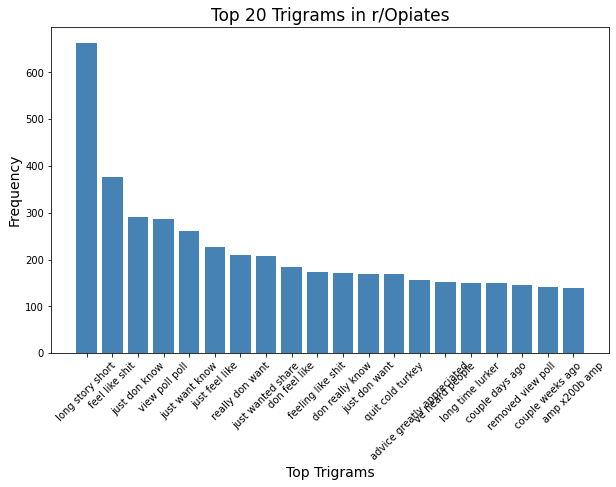

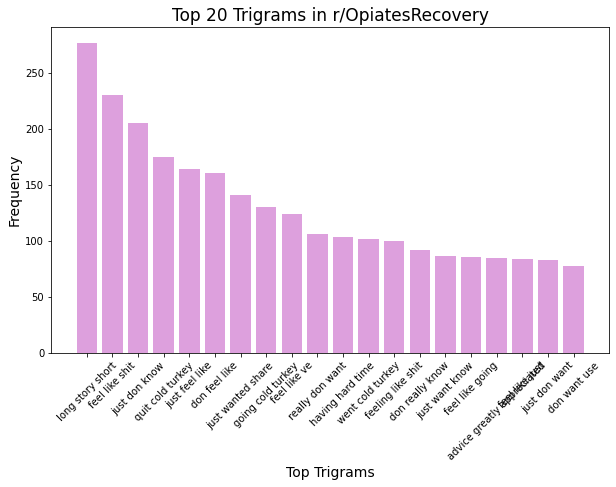

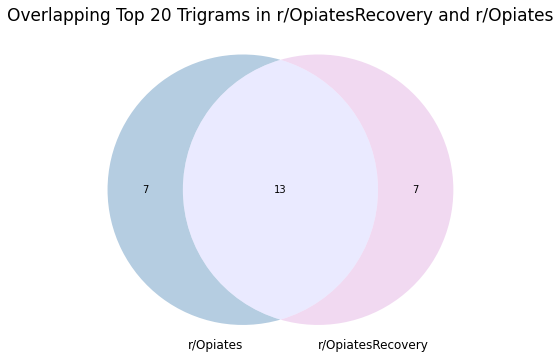

Overlapping Top 20 Trigrams in r/OpiatesRecovery and r/Opiates {'just feel like', 'just don know', 'don really know', 'just don want', 'really don want', 'quit cold turkey', 'just want know', 'long story short', 'don feel like', 'feeling like shit', 'feel like shit', 'advice greatly appreciated', 'just wanted share'}


In [ ]:
# visualization of trigram frequency data in r/Opiates
words_opiates = [word[0] for word in common_trigrams_opiates]
frequencies_opiates = [word[1] for word in common_trigrams_opiates]
plt.figure(figsize=(10, 6))
plt.bar(words_opiates, frequencies_opiates, color="steelblue")
plt.xticks(rotation=45)
plt.xlabel("Top Trigrams", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Top 20 Trigrams in r/Opiates", fontsize=17)
plt.savefig("Top 20 Trigrams in Opiates.jpeg") #save as jpeg
plt.show()

# visualization of trigram frequency data in r/OpiatesRecovery
words_opiates_recovery = [word[0] for word in common_trigrams_opiates_recovery]
frequencies_opiates_recovery = [word[1] for word in common_trigrams_opiates_recovery]
plt.figure(figsize=(10, 6))
plt.bar(words_opiates_recovery, frequencies_opiates_recovery, color="plum")
plt.xticks(rotation=45)
plt.xlabel("Top Trigrams", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Top 20 Trigrams in r/OpiatesRecovery", fontsize=17)
plt.savefig("Top 20 Trigrams in OpiatesRecovery.jpeg") #save as jpeg
plt.show()

# venn diagram of overlapping trigrams between subreddits
plt.figure(figsize=(10, 6))
venn2(
    subsets=[set(words_opiates), set(words_opiates_recovery)],
    set_labels=("r/Opiates", "r/OpiatesRecovery"),
    set_colors=("steelblue", "plum"),
)  # 2-element list of set objects
plt.title("Overlapping Top 20 Trigrams in r/OpiatesRecovery and r/Opiates", fontsize=17)
plt.savefig("Overlapping Top 20 Trigrams in OpiatesRecovery and Opiates.jpeg") #save as jpeg
plt.show()
print(
    f"Overlapping Top 20 Trigrams in r/OpiatesRecovery and r/Opiates {set(words_opiates).intersection(set(words_opiates_recovery))}"
)

## User Activity

In [ ]:
# look at posts from people who posted in both subreddits
common_authors = set(opiates["author"].unique()).intersection(
    set(opiates_recovery["author"].unique())
)
# cleaning the opiates dataframe
opiates_cleaned = opiates[
    opiates["author"].notnull()
]
opiates_cleaned["author_in_both"] = [
    (author in common_authors) & (author != "[deleted]") for author in opiates_cleaned.author
]
# dataframe of r/Opiates from users who posted in both subreddits
opiates_user_both = opiates_cleaned[opiates_cleaned["author_in_both"]]

# cleaning the opiates_recovery dataframe
opiates_recovery_cleaned = opiates_recovery[
    opiates_recovery["author"].notnull()
]
opiates_recovery_cleaned["author_in_both"] = [
    (author in common_authors) & (author != "[deleted]") for author in opiates_recovery_cleaned.author
]
# dataframe of r/OpiatesRecovery from users who posted in both subreddits
opiates_recovery_user_both = opiates_recovery_cleaned[opiates_recovery_cleaned["author_in_both"]]

# merges r/OpiatesRecovery and r/Opiates posts by users who posted in both subreddits
users_in_both = opiates_recovery_user_both[
    ["author", "month_year", "created","subreddit"]
].append(opiates_user_both[["author", "month_year", "created", "subreddit"]], ignore_index=True)

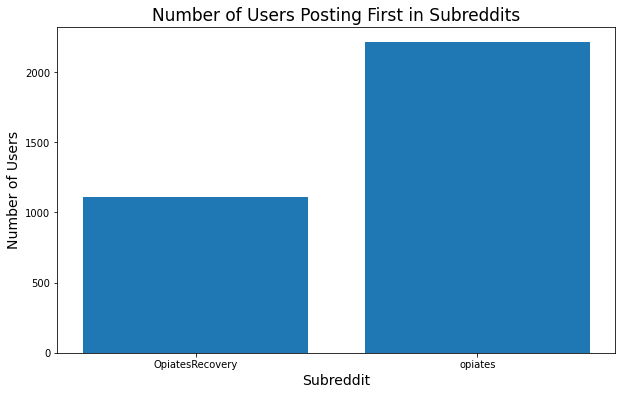

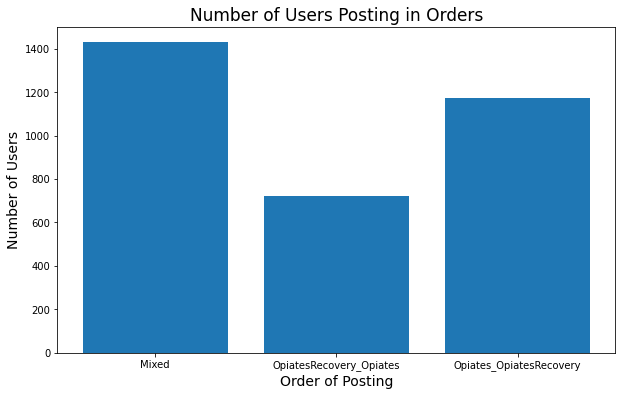

In [ ]:
# determines the order in which users posted (e.g., did they post first exclusively in r/Opiates
# then r/OpiatesRecovery, did they post first exclusively in r/OpiatesRecovery then r/Opiates, or
# did they switch between which they posted in over time)
author_info = users_in_both["author"].value_counts().rename_axis('username').reset_index(name='counts')

list_first_post = []
list_last_post = []
list_order = []

for author in author_info.username:
    authors_posts = users_in_both[users_in_both["author"] == author].sort_values(by=['created']).reset_index()
    first_post = authors_posts.iloc[0]["subreddit"]
    list_first_post.append(first_post)
    last_post = authors_posts.iloc[-1]["subreddit"]
    list_last_post.append(last_post)

    subreddits = list(authors_posts.loc[:,"subreddit"])
    subreddits_sorted = subreddits.copy()
    subreddits_sorted.sort()
    subreddits_sorted_rev = subreddits.copy()
    subreddits_sorted_rev.sort(reverse=True)

    # if the subreddits sorted is the same as the unsorted and the first post is opiates recovery,
    # then the user posted first exclusively in opiatesRecvoery then Opiates
    if (first_post == "OpiatesRecovery") & (subreddits == subreddits_sorted):
        order = "OpiatesRecovery_Opiates"
    # if the reversed subreddits sorted is the same as the unsorted and the first post is opiates,
    # then the user posted first exclusively in opiates then OpiatesRecovery
    elif (first_post == "opiates") & (subreddits == subreddits_sorted_rev):
        order = "Opiates_OpiatesRecovery"
    else:
        order = "Mixed"
    list_order.append(order)

author_info["first_post"] = list_first_post
author_info["last_post"] = list_last_post
author_info["order_post"] = list_order

# plots which subreddit users posted in first
firsts = author_info.groupby(by=[author_info.first_post]).count()
plt.figure(figsize=(10, 6))
plt.bar(firsts.index, firsts.counts)
plt.xlabel("Subreddit", fontsize=14)
plt.ylabel("Number of Users", fontsize=14)
plt.title("Number of Users Posting First in Subreddits", fontsize=17)
plt.savefig("Number of Users Posting First in Subreddits.jpeg") #save as jpeg
plt.show()

# plots the order that users posted in
orders = author_info.groupby(by=[author_info.order_post]).count()
plt.figure(figsize=(10, 6))
plt.bar(orders.index, orders.counts)
plt.xlabel("Order of Posting", fontsize=14)
plt.ylabel("Number of Users", fontsize=14)
plt.title("Number of Users Posting in Orders", fontsize=17)
plt.savefig("Number of Users Posting in Orders.jpeg") #save as jpeg
plt.show()